# UK Macroeconomic Deep-Dive (2019 - 2026)
This notebook analyzes the major shifts in the UK financial sector over the past few years, correlating the Bank of England Base Rate, UK Inflation, Mortgage Rates, and House Prices.

## Data Integration
We combine four core datasets extracted natively from the pipeline:
1. BoE Base Rate
2. ONS Consumer Prices Index (CPI)
3. BoE 2-Year Fixed Mortgage Rates (75% LTV)
4. HM Land Registry UK House Price Index


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Load Data
df_boe = pd.read_csv('../output/boe_base_rate.csv')
df_boe['Date'] = pd.to_datetime(df_boe['DATE'])
df_boe = df_boe.set_index('Date').resample('M').last()

df_inf = pd.read_csv('../output/ons_cpi_inflation.csv', skiprows=8, names=['Date', 'CPI_Rate'])
df_inf['Date'] = pd.to_datetime(df_inf['Date'], errors='coerce').dropna()
df_inf = df_inf.set_index('Date').resample('M').last()

df_mort2 = pd.read_csv('../output/boe_IUMTLMV.csv')
df_mort2['Date'] = pd.to_datetime(df_mort2['DATE'])
df_mort2 = df_mort2.set_index('Date').resample('M').last()

df_hpi = pd.read_csv('../output/uk_hpi_data.csv', low_memory=False)
df_hpi['Date'] = pd.to_datetime(df_hpi['Date'], format='%d/%m/%Y')
df_hpi_agg = df_hpi.groupby('Date')[['AveragePrice', '12m%Change']].mean()
df_hpi_agg = df_hpi_agg.resample('M').last()

# Merge
df = pd.concat([
    df_boe['IUDBEDR'].rename('BaseRate'),
    df_inf['CPI_Rate'],
    df_mort2['IUMTLMV'].rename('Mortgage2Y'),
    df_hpi_agg['AveragePrice'],
    df_hpi_agg['12m%Change'].rename('HPI_growth')
], axis=1)

df = df['2019-01-01':].ffill().dropna(subset=['BaseRate'])

# Display inline table of the most recent data
display(df.tail())


C:\Users\luigi_enjoy-digital\AppData\Local\Temp\ipykernel_36128\2922162780.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_boe = df_boe.set_index('Date').resample('M').last()
C:\Users\luigi_enjoy-digital\AppData\Local\Temp\ipykernel_36128\2922162780.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_inf = df_inf.set_index('Date').resample('M').last()
C:\Users\luigi_enjoy-digital\AppData\Local\Temp\ipykernel_36128\2922162780.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mort2 = df_mort2.set_index('Date').resample('M').last()


C:\Users\luigi_enjoy-digital\AppData\Local\Temp\ipykernel_36128\2922162780.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_hpi_agg = df_hpi_agg.resample('M').last()


,BaseRate,CPI_Rate,Mortgage2Y,AveragePrice,HPI_growth
Date,,,,,
2025-11-30,4.00,3.4,6.82,307933.212346,2.157531
2025-12-31,3.75,3.4,6.77,307347.488889,2.223457
2026-01-31,3.75,3.4,6.62,307347.488889,2.223457
2026-02-28,3.75,3.4,6.59,307347.488889,2.223457
2026-03-31,3.75,3.4,6.59,307347.488889,2.223457


## 1. The Inflation Shock & The Bank of England Response
Following the COVID-19 pandemic reopening, the UK experienced a massive surge in inflation.

**Context & Citations:**
* According to the ONS, UK CPI inflation peaked at a 41-year high of **11.1% in October 2022**. This was driven by energy prices soaring from the Ukraine conflict, motor fuels, and post-COVID supply chain bottlenecks ([ONS.gov.uk, 2022](https://www.ons.gov.uk)).
* In response, the Bank of England's Monetary Policy Committee (MPC) engaged in aggressive quantitative tightening. By August 2023, the Base Rate reached **5.25%**, a completely continuous 14-hike sprint to a 15-year high ([Bank of England, 2023](https://www.bankofengland.co.uk)).


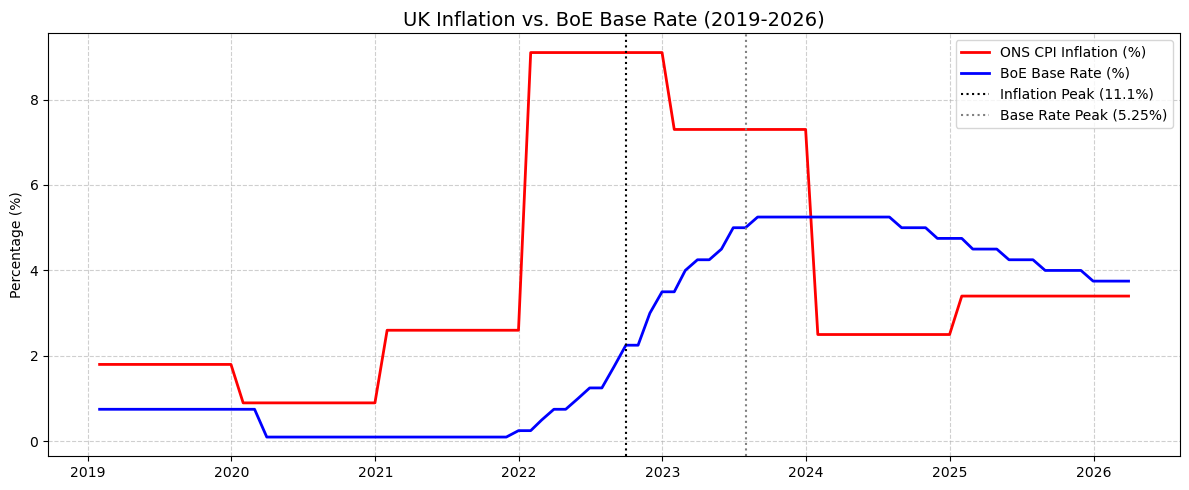

In [2]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['CPI_Rate'], label='ONS CPI Inflation (%)', color='red', linewidth=2)
plt.plot(df.index, df['BaseRate'], label='BoE Base Rate (%)', color='blue', linewidth=2)
plt.title('UK Inflation vs. BoE Base Rate (2019-2026)', fontsize=14)
plt.ylabel('Percentage (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(pd.to_datetime('2022-10-01'), color='black', linestyle=':', label='Inflation Peak (11.1%)')
plt.axvline(pd.to_datetime('2023-08-01'), color='gray', linestyle=':', label='Base Rate Peak (5.25%)')
plt.legend()
plt.tight_layout()
plt.savefig('../output/chart_inflation_baserate.png')
plt.show()


## 2. Mortgage Chaos & The Housing Market Cooling
While the rising Base Rate mechanically pushed up mortgage rates, a severe political shock caused an unprecedented spike.

**Context & Citations:**
* **The "Mini-Budget" Shock**: On September 23, 2022, Chancellor Kwasi Kwarteng announced unfunded tax cuts. The markets panicked, the pound crashed, and lenders withdrew thousands of mortgage products. Average 2-year fixed rates soared past 6% instantly ([MoneyWeek, The Guardian, 2022](https://www.theguardian.com)). 
* Meanwhile, House Prices had previously surged due to the **Stamp Duty Holiday** (July 2020 - Sept 2021) and the pandemic 'race for space' ([Unbiased.co.uk, CBRE](https://www.cbre.co.uk)). The high borrowing costs stemming from the mini-budget and high base rates eventually collapsed house price *growth*, pushing it negative in 2023.


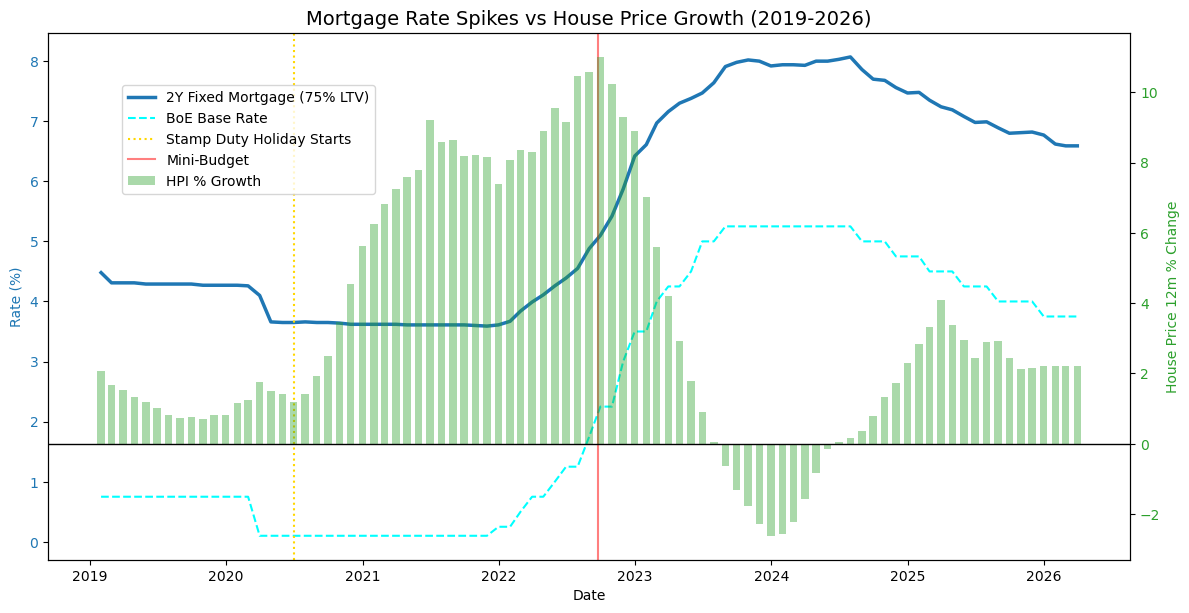

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Rate (%)', color=color)
ax1.plot(df.index, df['Mortgage2Y'], label='2Y Fixed Mortgage (75% LTV)', color=color, linewidth=2.5)
ax1.plot(df.index, df['BaseRate'], label='BoE Base Rate', color='cyan', linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:green'
ax2.set_ylabel('House Price 12m % Change', color=color)  
ax2.bar(df.index, df['HPI_growth'], width=20, alpha=0.4, color=color, label='HPI % Growth')
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(0, color='black', linewidth=1)

# Annotations
ax1.axvline(pd.to_datetime('2020-07-01'), color='gold', linestyle=':', label='Stamp Duty Holiday Starts')
ax1.axvline(pd.to_datetime('2022-09-23'), color='red', linestyle='-', alpha=0.5, label='Mini-Budget')

fig.tight_layout()  
plt.title('Mortgage Rate Spikes vs House Price Growth (2019-2026)', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.savefig('../output/chart_mortgage_hpi.png')
plt.show()
